In [3]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf

import utils

np.set_printoptions(precision=2)

tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)

In [5]:
data = np.loadtxt("./data/model_evaluation_data_1.csv", delimiter=",")

x = data[:, 0]
y = data[:, 1]

x = np.expand_dims(x, axis=1)
y = np.expand_dims(y, axis=1)

print(f"The shape of the inputs, x, is: {x.shape}")
print(f"The shape of the targets, y, is: {y.shape}")

The shape of the inputs, x, is: (50, 1)
The shape of the targets, y, is: (50, 1)


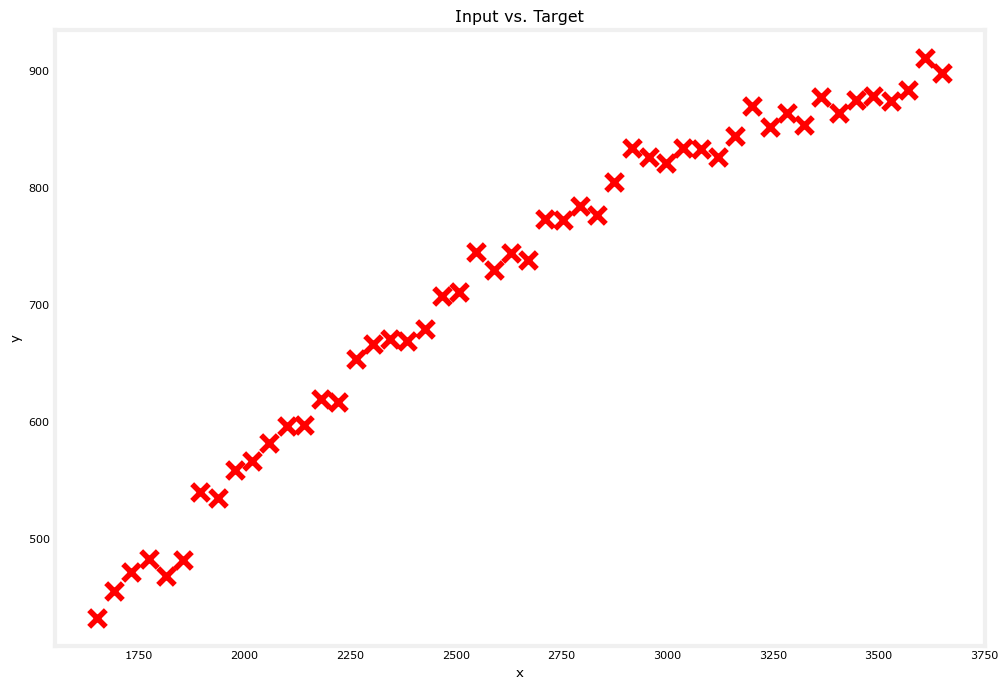

In [6]:
utils.plot_dataset(x=x, y=y, title="Input vs. Target")

In [7]:
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.40, random_state=1)

x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

del x_, y_
print(f"The shape of the training set (input) is: {x_train.shape}")
print(f"The shape of the training set (target) is: {y_train.shape}\n")

print(f"The shape of the cross validation set (input) is: {x_cv.shape}")
print(f"The shape of the cross validation set (target) is: {y_cv.shape}\n")

print(f"The shape of the test set (input is: {x_test.shape})")
print(f"The shape of the test set (target) is: {y_test.shape}")

The shape of the training set (input) is: (30, 1)
The shape of the training set (target) is: (30, 1)

The shape of the cross validation set (input) is: (10, 1)
The shape of the cross validation set (target) is: (10, 1)

The shape of the test set (input is: (10, 1))
The shape of the test set (target) is: (10, 1)


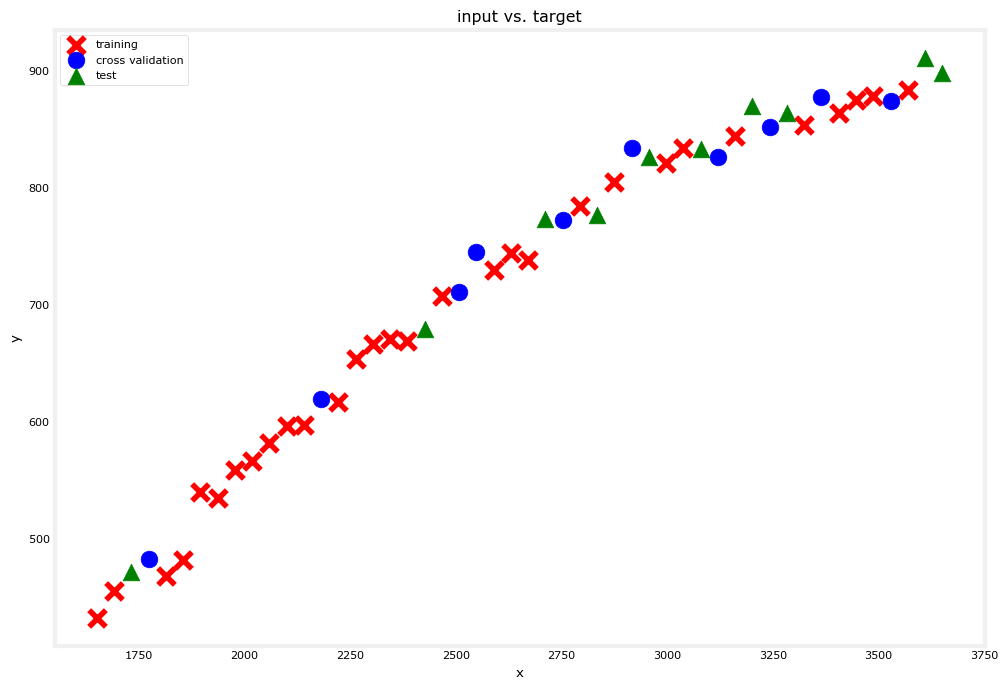

In [8]:
utils.plot_train_cv_test(x_train, y_train, x_cv, y_cv, x_test, y_test, title="Input vs. Target")

Computed mean of the training set:  2504.06
Computed standard deviation of the training set: 574.85


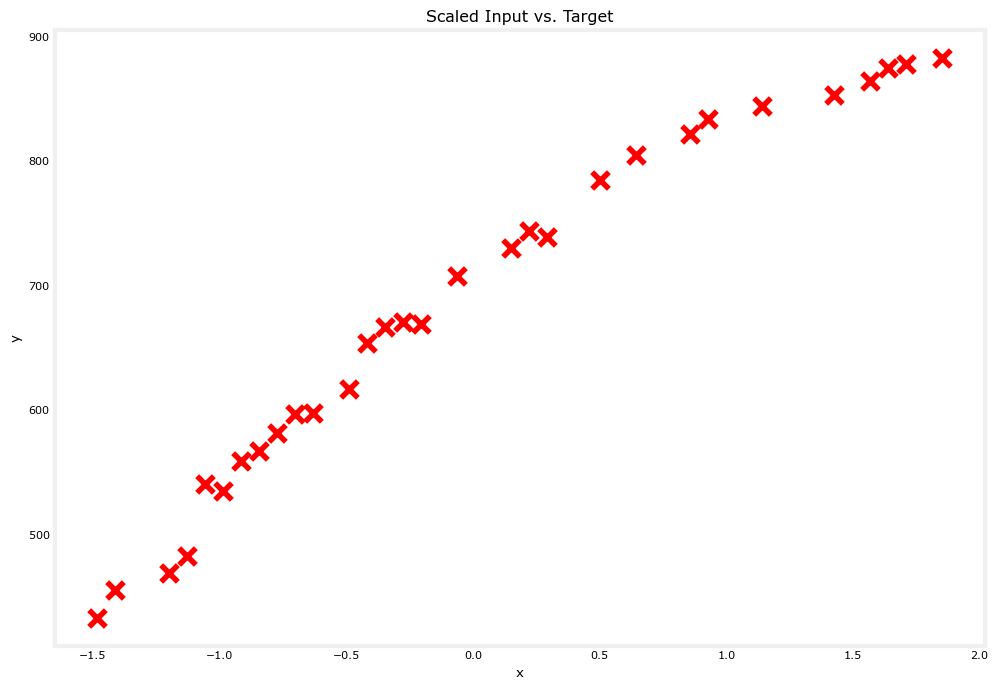

In [9]:
scaler_linear = StandardScaler()

x_train_scaled = scaler_linear.fit_transform(x_train)

print(f"Computed mean of the training set:  {scaler_linear.mean_.squeeze():.2f}")
print(f"Computed standard deviation of the training set: {scaler_linear.scale_.squeeze():.2f}")

utils.plot_dataset(x=x_train_scaled, y=y_train, title="Scaled Input vs. Target")

In [10]:
linear_model = LinearRegression()

linear_model.fit(x_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
yhat = linear_model.predict(x_train_scaled)

print(f"Training MSE (using sklearn function): {mean_squared_error(y_train, yhat) / 2}")

total_squared_error = 0

for i in range(len(yhat)):
    squared_error_i = (yhat[i] - y_train[i]) ** 2
    total_squared_error += squared_error_i

mse = total_squared_error / (2 * len(yhat))

print(f"Training MSE (for-loop implementation): {mse.squeeze()}")

Training MSE (using sklearn function): 406.19374192533127
Training MSE (for-loop implementation): 406.19374192533127


In [12]:
x_cv_scaled = scaler_linear.transform(x_cv)

print(f"Mean used to scale the CV set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the CV set: {scaler_linear.scale_.squeeze():.2f}")

yhat = linear_model.predict(x_cv_scaled)

print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")

Mean used to scale the CV set: 2504.06
Standard deviation used to scale the CV set: 574.85
Cross validation MSE: 551.7789026952216


In [14]:
poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_mapped = poly.fit_transform(x_train)

print(x_train_mapped[:5])

[[3.32e+03 1.11e+07]
 [2.34e+03 5.50e+06]
 [3.49e+03 1.22e+07]
 [2.63e+03 6.92e+06]
 [2.59e+03 6.71e+06]]


In [15]:
scaler_poly = StandardScaler()

x_train_mapped_scaled = scaler_poly.fit_transform(x_train_mapped)

print(x_train_mapped_scaled[:5])

[[ 1.43  1.47]
 [-0.28 -0.36]
 [ 1.71  1.84]
 [ 0.22  0.11]
 [ 0.15  0.04]]


In [16]:
model = LinearRegression()

model.fit(x_train_mapped_scaled, y_train)

yhat = model.predict(x_train_mapped_scaled)
print(f"Training MSE: {mean_squared_error(y_train, yhat) / 2}")

x_cv_mapped = poly.transform(x_cv)

x_cv_mapped_scaled = scaler_poly.transform(x_cv_mapped)

yhat = model.predict(x_cv_mapped_scaled)
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")

Training MSE: 49.111609334025175
Cross validation MSE: 87.69841211111921


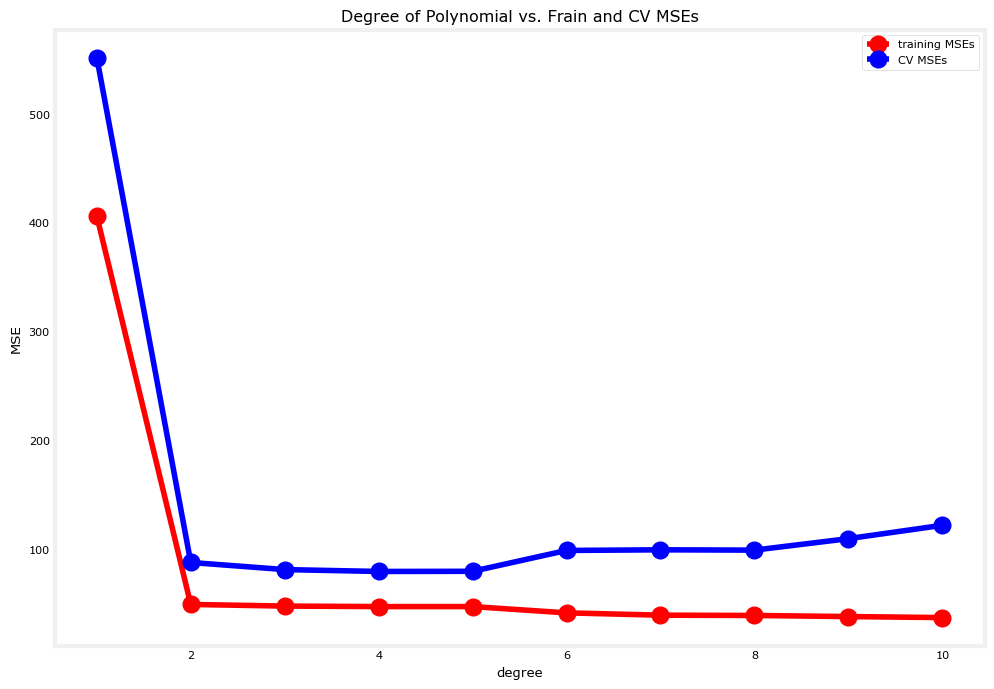

In [17]:
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

for degree in range(1,11):
    poly = PolynomialFeatures(degree, include_bias=False)
    x_train_mapped = poly.fit_transform(x_train)
    polys.append(poly)
    
    scaler_poly = StandardScaler()
    x_train_mapped_scaled = scaler_poly.fit_transform(x_train_mapped)
    scalers.append(scaler_poly)
    
    model = LinearRegression()
    model.fit(x_train_mapped_scaled, y_train )
    models.append(model)
    
    yhat = model.predict(x_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    train_mses.append(train_mse)
    
    x_cv_mapped = poly.transform(x_cv)
    x_cv_mapped_scaled = scaler_poly.transform(x_cv_mapped)
    
    yhat = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat) / 2
    cv_mses.append(cv_mse)
    
degrees = range(1, 11)
utils.plot_train_cv_mses(degrees, train_mses, cv_mses, title="Degree of Polynomial vs. Frain and CV MSEs")

In [18]:
degree = np.argmin(cv_mses) + 1
print(f"Lowest CV MSE is found in the model with degree = {degree}")

Lowest CV MSE is found in the model with degree = 4


In [19]:
x_test_mapped = polys[degree - 1].transform(x_test)

x_test_mapped_scaled = scalers[degree - 1].transform(x_test_mapped)

yhat = models[degree - 1].predict(x_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Training MSE: {train_mses[degree - 1]:.2f}")
print(f"Cross Validation MSE: {cv_mses[degree - 1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 47.15
Cross Validation MSE: 79.43
Test MSE: 104.63


In [20]:
degree = 1
poly = PolynomialFeatures(degree, include_bias=False)
x_train_mapped = poly.fit_transform(x_train)
x_cv_mapped = poly.transform(x_cv)
x_test_mapped = poly.transform(x_test)

In [21]:
scaler = StandardScaler()
x_train_mapped_scaled = scaler.fit_transform(x_train_mapped)
x_cv_mapped_scaled = scaler.transform(x_cv_mapped)
x_test_mapped_scaled = scaler.transform(x_test_mapped)

In [22]:
nn_train_mses = []
nn_cv_mses = []

nn_models = utils.build_models()

for model in nn_models:
    model.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    )

    print(f"Training {model.name}...")
    
    model.fit(
        x_train_mapped_scaled, y_train,
        epochs=300,
        verbose=0
    )
    
    print("Done!\n")

    yhat = model.predict(x_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    nn_train_mses.append(train_mse)
    
    yhat = model.predict(x_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat) / 2
    nn_cv_mses.append(cv_mse)

print("RESULTS:")
for model_num in range(len(nn_train_mses)):
    print(
        f"Model {model_num + 1}: Training MSE: {nn_train_mses[model_num]:.2f}, " +
        f"CV MSE: {nn_cv_mses[model_num]:.2f}"
        )

Training model_1...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Training model_2...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Training model_3...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
RESULTS:
Model 1: Training MSE: 210.94, CV MSE: 303.41
Model 2: Training MSE: 73.40, CV MSE: 112.49
Model 3: Training MSE: 406.19, CV MSE: 551.78


In [23]:
model_num = 3

yhat = nn_models[model_num-1].predict(x_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Selected Model: {model_num}")
print(f"Training MSE: {nn_train_mses[model_num - 1]:.2f}")
print(f"Cross Validation MSE: {nn_cv_mses[model_num - 1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Selected Model: 3
Training MSE: 406.19
Cross Validation MSE: 551.78
Test MSE: 467.26


In [25]:
data = np.loadtxt("./data/model_evaluation_data_2.csv", delimiter=',')

x_bc = data[:, :-1]
y_bc = data[:, -1]

y_bc = np.expand_dims(y_bc, axis=1)

print(f"The shape of the inputs x is: {x_bc.shape}")
print(f"The shape of the targets y is: {y_bc.shape}")

The shape of the inputs x is: (200, 2)
The shape of the targets y is: (200, 1)


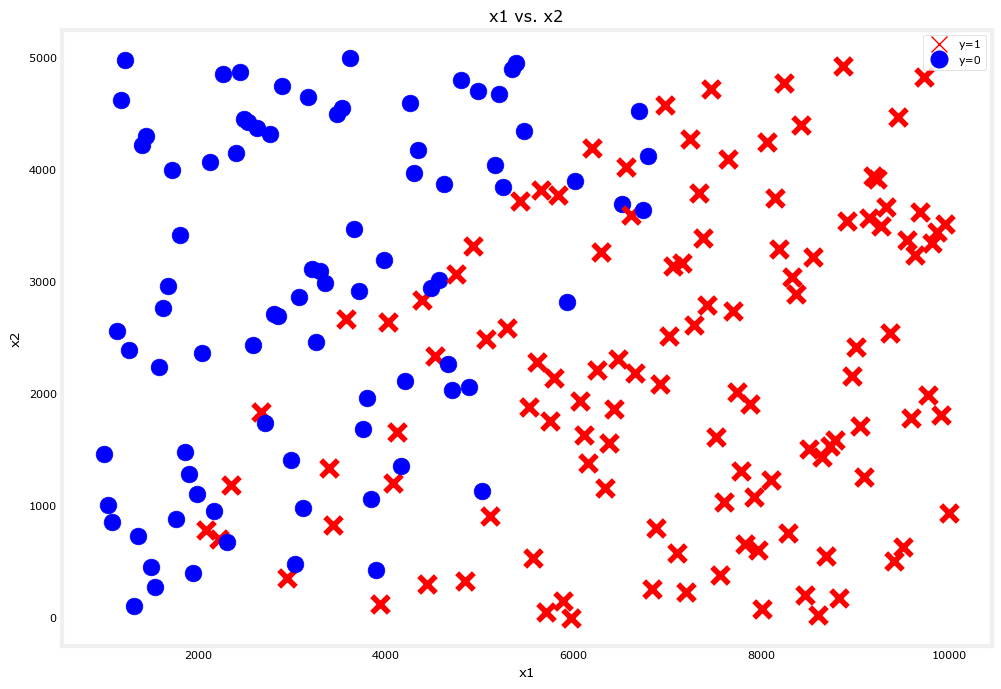

In [26]:
utils.plot_bc_dataset(x=x_bc, y=y_bc, title="x1 vs. x2")

In [28]:
from sklearn.model_selection import train_test_split

x_bc_train, x_, y_bc_train, y_ = train_test_split(x_bc, y_bc, test_size=0.40, random_state=1)

x_bc_cv, x_bc_test, y_bc_cv, y_bc_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

del x_, y_

print(f"The shape of the training set (input) is: {x_bc_train.shape}")
print(f"The shape of the training set (target) is: {y_bc_train.shape}\n")

print(f"The shape of the cross validation set (input) is: {x_bc_cv.shape}")
print(f"The shape of the cross validation set (target) is: {y_bc_cv.shape}\n")

print(f"The shape of the test set (input) is: {x_bc_test.shape}")
print(f"The shape of the test set (target) is: {y_bc_test.shape}")

The shape of the training set (input) is: (120, 2)
The shape of the training set (target) is: (120, 1)

The shape of the cross validation set (input) is: (40, 2)
The shape of the cross validation set (target) is: (40, 1)

The shape of the test set (input) is: (40, 2)
The shape of the test set (target) is: (40, 1)


In [29]:
scaler_linear = StandardScaler()

x_bc_train_scaled = scaler_linear.fit_transform(x_bc_train)
x_bc_cv_scaled = scaler_linear.transform(x_bc_cv)
x_bc_test_scaled = scaler_linear.transform(x_bc_test)

In [30]:
probabilities = np.array([0.2, 0.6, 0.7, 0.3, 0.8])

predictions = np.where(probabilities >= 0.5, 1, 0)

ground_truth = np.array([1, 1, 1, 1, 1])

misclassified = 0

num_predictions = len(predictions)

for i in range(num_predictions):
    if predictions[i] != ground_truth[i]:
        misclassified += 1

fraction_error = misclassified/num_predictions

print(f"Probabilities: {probabilities}")
print(f"Predictions with threshold = 0.5: {predictions}")
print(f"Targets: {ground_truth}")
print(f"Fraction of misclassified data (for-loop): {fraction_error}")
print(f"Fraction of misclassified data (with np.mean()): {np.mean(predictions != ground_truth)}")

Probabilities: [0.2 0.6 0.7 0.3 0.8]
Predictions with threshold = 0.5: [0 1 1 0 1]
Targets: [1 1 1 1 1]
Fraction of misclassified data (for-loop): 0.4
Fraction of misclassified data (with np.mean()): 0.4


In [31]:
nn_train_error = []
nn_cv_error = []

models_bc = utils.build_models()

for model in models_bc:
    model.compile(
     loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
     optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    )

    print(f"Training {model.name}...")

    model.fit(
        x_bc_train_scaled, y_bc_train,
        epochs=200,
        verbose=0
    )
    
    print("Done!\n")
    
    threshold = 0.5
    
    yhat = model.predict(x_bc_train_scaled)
    yhat = tf.math.sigmoid(yhat)
    yhat = np.where(yhat >= threshold, 1, 0)
    train_error = np.mean(yhat != y_bc_train)
    nn_train_error.append(train_error)

    yhat = model.predict(x_bc_cv_scaled)
    yhat = tf.math.sigmoid(yhat)
    yhat = np.where(yhat >= threshold, 1, 0)
    cv_error = np.mean(yhat != y_bc_cv)
    nn_cv_error.append(cv_error)

for model_num in range(len(nn_train_error)):
    print(
        f"Model {model_num + 1}: Training Set Classification Error: {nn_train_error[model_num]:.5f}, " +
        f"CV Set Classification Error: {nn_cv_error[model_num]:.5f}"
    )

Training model_1...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training model_2...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Training model_3...
Done!

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Model 1: Training Set Classification Error: 0.05000, CV Set Classification Error: 0.17500
Model 2: Training Set Classification Error: 0.03333, CV Set Classification Error: 0.17500
Model 3: Training Set Classification Error: 0.01667, CV Set Classification Error: 0.15000


In [32]:
model_num = 3

yhat = models_bc[model_num - 1].predict(x_bc_test_scaled)
yhat = tf.math.sigmoid(yhat)
yhat = np.where(yhat >= threshold, 1, 0)
nn_test_error = np.mean(yhat != y_bc_test)

print(f"Selected Model: {model_num}")
print(f"Training Set Classification Error: {nn_train_error[model_num-1]:.4f}")
print(f"CV Set Classification Error: {nn_cv_error[model_num-1]:.4f}")
print(f"Test Set Classification Error: {nn_test_error:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Selected Model: 3
Training Set Classification Error: 0.0167
CV Set Classification Error: 0.1500
Test Set Classification Error: 0.1500
